# Lab 01: The Objective, Verified

**Tier 1 lab.** Every cell here ran on ordinary hardware during the build and every claim is
checked with an `assert` rather than merely stated. No model is trained. Nothing is
downloaded.

That is not a limitation, it is the point. Everything in this notebook operates on synthetic
logit tensors, random numbers standing in for real model outputs, because the distillation
*objective* is independent of where the logits came from, and the objective is where
practitioners actually introduce bugs. A wrong temperature scaling, an inverted beta, a mask
that is off by one position: none of these raise an exception, none of them make the loss
curve look strange, and all of them silently train the wrong thing.

By the end you will have verified, numerically:

1. The gradient of the softened KL is exactly `(1/T)(q - p)`, which is *why* the `T²` factor exists.
2. At high temperature, KD degenerates into mean-squared error on logits.
3. Forward and reverse KL produce visibly different students when the student cannot cover the teacher.
4. TRL's `beta` runs in the opposite direction from several popular write-ups of the GKD paper.
5. Top-k logit caching introduces a bias whose sign depends on how you handle the missing mass.
6. The mask alignment that every next-token distillation loop gets wrong at least once.

Course convention: `p` is always the **teacher**, `q` is always the **student**.

In [1]:
import os
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")   # widget progress bars crash some notebook stacks; plain logs are fine

import sys, math
sys.path.insert(0, "../code")

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from kd_core import (
    kl_divergence, gjsd, tvd, hinton_kd_loss,
    make_topk_cache, topk_forward_kl, topk_truncation_bias, bytes_per_token_cache,
    shift_for_next_token, completion_mask_from_prompt_lens, onpolicy_mask,
    mean_entropy, top1_agreement,
)

torch.manual_seed(0)
torch.set_printoptions(precision=4, sci_mode=False)
print("torch", torch.__version__)

torch 2.13.0+cpu


## 1. Temperature is a knob on how much of the teacher you listen to

The softened distribution divides every logit by a constant $T$, the temperature, before the
softmax:

$$q_i = \frac{\exp(z_i/T)}{\sum_j \exp(z_j/T)}$$

Low `T` sharpens the distribution toward its argmax (the single highest-scoring token) and
throws away the ranking among the non-top tokens, which is the entire signal distillation is
supposed to be transferring. High `T` flattens the distribution toward uniform and starts
weighting the teacher's noise floor, the tokens it has effectively ruled out and scores
essentially at random, as heavily as its real preferences.

"Dark knowledge" is Hinton's name for the information carried by the *relative* probabilities
among the tokens the teacher rejected: which wrong answers the teacher considers nearly
right, and which it considers absurd. A hard label carries none of that. Watch what
temperature does to it.

In [2]:
logits = torch.tensor([8.0, 5.5, 5.0, 1.0, 0.5, -2.0, -3.0])
labels = ["the", "a", "an", "cat", "dog", "xylophone", "qq"]

print(f"{'T':>5} | {'entropy':>8} | " + " ".join(f"{l:>10}" for l in labels))
print("-" * 92)
for T in (0.25, 0.5, 1.0, 2.0, 4.0, 10.0):
    p = F.softmax(logits / T, dim=-1)
    H = float(-(p * p.clamp_min(1e-12).log()).sum())
    print(f"{T:>5} | {H:>8.4f} | " + " ".join(f"{v:>10.6f}" for v in p.tolist()))

    T |  entropy |        the          a         an        cat        dog  xylophone         qq
--------------------------------------------------------------------------------------------
 0.25 |   0.0006 |   0.999948   0.000045   0.000006   0.000000   0.000000   0.000000   0.000000
  0.5 |   0.0573 |   0.990866   0.006676   0.002456   0.000001   0.000000   0.000000   0.000000
  1.0 |   0.4479 |   0.882302   0.072424   0.043927   0.000805   0.000488   0.000040   0.000015
  2.0 |   1.0527 |   0.635253   0.182003   0.141744   0.019183   0.014940   0.004280   0.002596
  4.0 |   1.5783 |   0.403101   0.215764   0.190411   0.070048   0.061817   0.033089   0.025769
 10.0 |   1.8748 |   0.238702   0.185901   0.176835   0.118536   0.112755   0.087814   0.079457


Read the `T=0.25` row of the table above: the distribution is essentially one-hot
(probability 1 on a single token, 0 everywhere else), so a student matching it learns nothing
it would not have learned from a hard label. Read the `T=10` row: `xylophone` is now within a
factor of three of `the`, so the student spends capacity modelling the teacher's garbage tail
as if it were signal.

The useful range is in between, and it is task-dependent. Peaked domains, where the teacher
is usually near-certain about the next token (code, math, structured output), tolerate lower
`T`. Diffuse domains, where many continuations are genuinely plausible (open-ended prose),
need more.

## 2. The gradient identity, and why `T²` exists

For forward KL against a fixed teacher, the derivative of the loss with respect to a student
logit is

$$\frac{\partial \mathcal{L}}{\partial z_i} = \frac{1}{T}\left(q_i - p_i\right)$$

Note the $1/T$ out front. Raising the temperature shrinks the gradient directly through that
factor, and the residual $q_i - p_i$ *also* shrinks roughly as $1/T$, because softening
pushes both distributions toward uniform and therefore toward each other. Multiply the two
effects together and the total gradient falls off like $1/T^2$. Now consider the standard
combined loss: a soft distillation term at temperature $T$, mixed by a coefficient `alpha`
with a hard-label cross-entropy computed at $T=1$. If you change $T$, the soft term's
gradient scales by $1/T^2$ while the hard term's gradient does not move, so you have
silently changed the relative weight of the two terms even though `alpha` stayed the same.
Multiplying the soft term by $T^2$ cancels that scaling, and that is what keeps `alpha`
meaning what you think it means.

Let us confirm the identity against autograd rather than trusting the algebra.

In [3]:
B, T_len, V = 2, 5, 64
student = torch.randn(B, T_len, V, requires_grad=True)
teacher = torch.randn(B, T_len, V)
mask = torch.ones(B, T_len, dtype=torch.bool)
mask[1, 3:] = False          # a short sequence in the batch, so masking is exercised

for temp in (1.0, 2.0, 4.0):
    student.grad = None
    loss = kl_divergence(student, teacher, mask, T=temp,
                         direction="forward", scale_by_T2=False)
    loss.backward()

    q = F.softmax(student / temp, dim=-1)
    p = F.softmax(teacher / temp, dim=-1)
    N = int(mask.sum())
    analytic = (1.0 / temp) * (q - p) * mask[..., None] / N

    err = (student.grad - analytic).abs().max().item()
    print(f"T={temp:<4}  max|autograd - (1/T)(q-p)/N| = {err:.3e}")
    assert err < 1e-6, "gradient identity failed"

print("\nverified: the softened-KL gradient is exactly (1/T)(q - p)")

T=1.0   max|autograd - (1/T)(q-p)/N| = 7.451e-09
T=2.0   max|autograd - (1/T)(q-p)/N| = 8.149e-10
T=4.0   max|autograd - (1/T)(q-p)/N| = 3.492e-10

verified: the softened-KL gradient is exactly (1/T)(q - p)


In [4]:
rows = []
for temp in (1.0, 2.0, 4.0, 8.0):
    student.grad = None
    kl_divergence(student, teacher, mask, T=temp, scale_by_T2=False).backward()
    raw = student.grad.norm().item()
    student.grad = None
    kl_divergence(student, teacher, mask, T=temp, scale_by_T2=True).backward()
    scaled = student.grad.norm().item()
    rows.append((temp, raw, scaled))

print(f"{'T':>5} | {'grad norm, no T^2':>18} | {'grad norm, with T^2':>20}")
print("-" * 50)
for temp, raw, scaled in rows:
    print(f"{temp:>5} | {raw:>18.6f} | {scaled:>20.6f}")
print("\nWithout the correction the gradient falls ~64x going from T=1 to T=8.")
print("With it, the scale is stable and `alpha` keeps its meaning.")

    T |  grad norm, no T^2 |  grad norm, with T^2
--------------------------------------------------
  1.0 |           0.094660 |             0.094660
  2.0 |           0.017461 |             0.069844
  4.0 |           0.004000 |             0.064003
  8.0 |           0.000977 |             0.062529

Without the correction the gradient falls ~64x going from T=1 to T=8.
With it, the scale is stable and `alpha` keeps its meaning.


## 3. At high temperature, KD is just MSE on logits

Expand the softmax for large `T`, using the first-order approximation
$\exp(z_i/T) \approx 1 + z_i/T$, which becomes accurate once $z_i/T$ is small. With
zero-mean logits (student logits $z$, teacher logits $v$),

$$q_i \approx \frac{1}{V} + \frac{z_i}{VT}, \qquad p_i \approx \frac{1}{V} + \frac{v_i}{VT}$$

so the gradient becomes $\frac{z_i - v_i}{VT^2}$, which is exactly the gradient of the
mean-squared-error objective $\frac{1}{2VT^2}\sum_i (z_i - v_i)^2$. In other words, at high
enough temperature, matching softened distributions is the same thing as directly regressing
the student's logits onto the teacher's.

This is worth knowing because it tells you what you lose at high `T`: all the structure the
softmax imposes, probabilities that compete for a fixed budget of mass, leaving plain
regression onto teacher logits. It also explains why some pipelines skip the softmax
entirely and regress logits directly: they are running this high-temperature limit on
purpose.

In [5]:
sz = (student - student.mean(-1, keepdim=True)).detach().requires_grad_(True)
tz = teacher - teacher.mean(-1, keepdim=True)
temp = 100.0

sz.grad = None
kl_divergence(sz, tz, mask, T=temp, scale_by_T2=False).backward()
kl_grad = sz.grad.clone()

sz.grad = None
mse = (((sz - tz) ** 2).sum(-1) * mask).sum() / (2 * V * temp**2 * int(mask.sum()))
mse.backward()

diff = (kl_grad - sz.grad).abs().max().item()
print(f"max |grad(high-T KL) - grad(logit MSE)| = {diff:.3e}")
assert diff < 1e-6
print("verified: at T=100 the KD gradient and the logit-MSE gradient coincide")

max |grad(high-T KL) - grad(logit MSE)| = 1.374e-08
verified: at T=100 the KD gradient and the logit-MSE gradient coincide


## 4. Forward versus reverse KL, shown rather than asserted

The standard picture is that forward KL is *mode covering* and reverse KL is *mode seeking*.
A mode is a peak of the distribution, a region of concentrated probability. Mode covering
means the student spreads itself so that every region the teacher cares about gets some mass;
mode seeking means the student picks one region it can represent well and commits to it. That
picture only becomes real when the student **cannot** represent the teacher, and a smaller
model that cannot fully match its teacher is the situation you are always in when distilling.

So constrain the student honestly: give it a single-bump family with two free parameters
(location and width), a distribution that has exactly one peak by construction, and ask it to
fit a bimodal teacher, one with two separated peaks. Whichever objective you pick decides
what the student does about the mode it cannot reach.

In [6]:
V_demo = 60
x = torch.arange(V_demo, dtype=torch.float32)

def bump(mu, sigma, scale=1.0):
    return -scale * (x - mu) ** 2 / (2 * sigma ** 2)

teacher_logits = torch.logsumexp(torch.stack([
    bump(15.0, 3.0) + math.log(0.55),
    bump(44.0, 3.0) + math.log(0.45),
]), dim=0)
p_teacher = F.softmax(teacher_logits, dim=-1)

def fit_student(direction, steps=1500, lr=0.05):
    mu = torch.tensor(29.5, requires_grad=True)      # start exactly between the modes
    log_sigma = torch.tensor(1.5, requires_grad=True)
    opt = torch.optim.Adam([mu, log_sigma], lr=lr)
    m = torch.ones(1, 1, dtype=torch.bool)
    for _ in range(steps):
        s_logits = bump(mu, log_sigma.exp()).view(1, 1, -1)
        loss = kl_divergence(s_logits, teacher_logits.view(1, 1, -1), m,
                             direction=direction, scale_by_T2=False)
        opt.zero_grad(); loss.backward(); opt.step()
    with torch.no_grad():
        q = F.softmax(bump(mu, log_sigma.exp()), dim=-1)
    return q, float(mu), float(log_sigma.exp()), float(loss)

q_fwd, mu_f, sd_f, l_f = fit_student("forward")
q_rev, mu_r, sd_r, l_r = fit_student("reverse")

print(f"forward KL  -> mu={mu_f:6.2f}  sigma={sd_f:5.2f}   (teacher modes at 15 and 44)")
print(f"reverse KL  -> mu={mu_r:6.2f}  sigma={sd_r:5.2f}")

/tmp/ipykernel_539/3776690826.py:25: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:822.)
  return q, float(mu), float(log_sigma.exp()), float(loss)


forward KL  -> mu= 26.93  sigma=19.63   (teacher modes at 15 and 44)
reverse KL  -> mu= 27.41  sigma=18.98


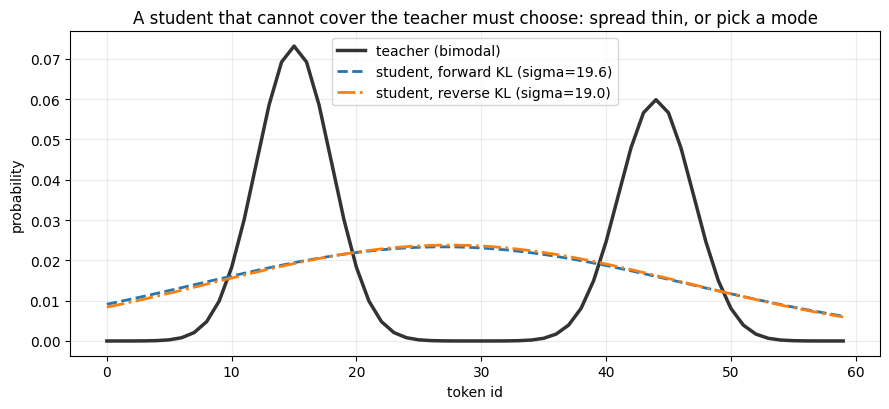

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(x, p_teacher, lw=2.5, label="teacher (bimodal)", color="#333333")
ax.plot(x, q_fwd, lw=2, ls="--", label=f"student, forward KL (sigma={sd_f:.1f})")
ax.plot(x, q_rev, lw=2, ls="-.", label=f"student, reverse KL (sigma={sd_r:.1f})")
ax.set_xlabel("token id"); ax.set_ylabel("probability")
ax.set_title("A student that cannot cover the teacher must choose: spread thin, or pick a mode")
ax.legend(); ax.grid(alpha=0.25)
plt.tight_layout(); plt.savefig("../figures/fwd_vs_rev_kl.png", dpi=130)
plt.show()

Forward KL charges the student heavily for assigning near-zero probability anywhere the
teacher has real mass (the loss contains the ratio of teacher to student probability inside a
log, which grows without limit as the student's probability approaches zero). So the student
widens until it spans both modes and, in doing so, places its own peak in the valley
*between* them, a region the teacher considers unlikely. In text generation this is the model
that hedges, waffles, and occasionally emits something neither the teacher nor the data would
have produced.

Reverse KL runs the penalty the other way: the student is charged for putting its own mass
where the teacher has little, but pays nothing for ignoring teacher mass it cannot cover. So
it abandons the mode it cannot reach and commits to the one it can. The output is sharper and
more usable, and the diversity you lost is invisible unless you go looking for it. That is
the trade, and it is why the literature on distillation failure modes spends so much time on
entropy collapse, the runaway version of this commitment in which the student's
distributions keep narrowing until its output is nearly deterministic.

Neither is correct in the abstract. Forward KL is the right choice when you intend to sample
broadly from the student, or to run reinforcement learning on it afterwards, because RL
explores by sampling and needs those multiple plausible continuations still intact. Reverse
KL is the right choice when you want a small model that behaves crisply on a narrow task.

## 5. The `beta` convention will bite you

`gjsd`, the generalised Jensen-Shannon divergence, interpolates between the two directions of
KL with a mixing parameter `beta`. But the direction of `beta`, meaning which end of its
range corresponds to which KL, is **not** consistent across the literature and the tooling,
and getting it backwards trains the opposite objective with no error and no warning: the loss
still goes down, just toward the wrong target.

The current TRL documentation for `DistillationConfig` states that `beta=0.0` approximates
forward KL and `beta=1.0` approximates reverse KL. Several popular explanations of the GKD
paper use the reverse labelling. `kd_core` follows TRL. Verify it here, and re-verify it any
time you inherit a config from somewhere else.

In [8]:
t1 = torch.tensor([[[3.0, 0.0, -1.0, 2.0]]])
s1 = torch.tensor([[[0.0, 2.0,  1.0, -1.0]]])
m1 = torch.ones(1, 1, dtype=torch.bool)

fwd = kl_divergence(s1, t1, m1, direction="forward", scale_by_T2=False).item()
rev = kl_divergence(s1, t1, m1, direction="reverse", scale_by_T2=False).item()
print(f"true forward KL(teacher||student) = {fwd:.5f}")
print(f"true reverse KL(student||teacher) = {rev:.5f}\n")

print(f"{'beta':>7} | {'JSD_beta':>10} | {'rescaled':>10} | approaches")
print("-" * 52)
for b in (0.001, 0.01, 0.25, 0.5, 0.75, 0.99, 0.999):
    g = gjsd(s1, t1, m1, beta=b).item()
    scale, name = (b, "forward KL") if b < 0.5 else (1 - b, "reverse KL")
    tag = name if (b < 0.05 or b > 0.95) else "(interpolating)"
    print(f"{b:>7} | {g:>10.6f} | {g/scale:>10.5f} | {tag}")

assert abs(gjsd(s1, t1, m1, beta=0.001).item() / 0.001 - fwd) < 0.01
assert abs(gjsd(s1, t1, m1, beta=0.999).item() / 0.001 - rev) < 0.02
print("\nverified: beta -> 0 recovers forward KL, beta -> 1 recovers reverse KL (TRL convention)")

true forward KL(teacher||student) = 1.84121
true reverse KL(student||teacher) = 2.32564

   beta |   JSD_beta |   rescaled | approaches
----------------------------------------------------
  0.001 |   0.001838 |    1.83786 | forward KL
   0.01 |   0.018088 |    1.80878 | forward KL
   0.25 |   0.310710 |    1.24284 | (interpolating)
    0.5 |   0.412470 |    0.82494 | (interpolating)
   0.75 |   0.334102 |    1.33641 | (interpolating)
   0.99 |   0.022527 |    2.25271 | reverse KL
  0.999 |   0.002318 |    2.31796 | reverse KL

verified: beta -> 0 recovers forward KL, beta -> 1 recovers reverse KL (TRL convention)


## 6. Top-k logit caching, and the bias nobody measures

You cannot store dense teacher distributions, meaning the teacher's full probability vector
over the entire vocabulary at every token position. Do the arithmetic for a modern
vocabulary before you argue about it; the cell below prices it in gigabytes.

In [9]:
for name, vocab in [("Llama 3 / 3.1", 128256), ("Qwen2.5 / Qwen3", 151936), ("Gemma 2/3", 256000)]:
    s = bytes_per_token_cache(vocab, k=32)
    print(f"{name:<18} V={vocab:>7}  dense {s['dense_gb_per_1M_tokens']:>7.1f} GB/1M tok"
          f"   top-32 {s['topk_gb_per_1M_tokens']:>5.3f} GB/1M tok"
          f"   ({s['compression']:>6.0f}x)")

Llama 3 / 3.1      V= 128256  dense   256.5 GB/1M tok   top-32 0.194 GB/1M tok   (  1322x)
Qwen2.5 / Qwen3    V= 151936  dense   303.9 GB/1M tok   top-32 0.194 GB/1M tok   (  1566x)
Gemma 2/3          V= 256000  dense   512.0 GB/1M tok   top-32 0.194 GB/1M tok   (  2639x)


Three hundred gigabytes per million tokens is not a caching strategy, it is a disk
purchase. So everyone stores top-k instead: only the k highest-probability entries at each
position. The question is what you do about the probability mass you threw away, and there
are two answers with **opposite** biases:

- **Renormalise** over the retained k: rescale the kept probabilities so they sum to 1. This
  pretends the teacher never considered anything else, which makes the teacher look more
  confident than it was, and *overstates* the divergence.
- **Tail bucket**: keep the total discarded mass as one extra aggregate entry and match the
  student's total mass on those same discarded tokens against it. One extra term in the sum,
  and it *understates* rather than overstates, because one lumped bucket cannot see how the
  mass is arranged among the individual tokens inside the tail.

Measure both. Note that the size of the effect depends entirely on how peaked your teacher
is: the more of the mass the top-k entries capture, the less there is left to be wrong
about.

In [10]:
def report(tag, s_logits, t_logits, m, ks=(1, 4, 16, 64)):
    print(f"\n{tag}")
    print(f"{'k':>4} | {'mass kept':>10} | {'dense KL':>9} | {'renorm':>9} | {'+tail':>9} "
          f"| {'renorm err':>11} | {'tail err':>9}")
    print("-" * 82)
    for r in topk_truncation_bias(s_logits, t_logits, m, ks=ks):
        print(f"{r['k']:>4} | {r['mean_mass_covered']:>10.4f} | {r['dense_kl']:>9.4f} "
              f"| {r['renorm_kl']:>9.4f} | {r['tail_bucket_kl']:>9.4f} "
              f"| {r['renorm_rel_err']:>10.1%} | {r['tail_rel_err']:>8.1%}")

# Flat teacher: the pathological case. Random logits are nearly uniform.
report("FLAT teacher (random logits, V=64) — worst case for top-k",
       student.detach(), teacher, mask)

# Peaked teacher: what a trained model on a well-specified task actually looks like.
peaked_teacher = teacher * 6.0
report("PEAKED teacher (same logits scaled 6x) — realistic case",
       student.detach(), peaked_teacher, mask)


FLAT teacher (random logits, V=64) — worst case for top-k
   k |  mass kept |  dense KL |    renorm |     +tail |  renorm err |  tail err
----------------------------------------------------------------------------------
   1 |     0.1101 |    1.0503 |    5.6087 |    0.2783 |     434.0% |   -73.5%
   4 |     0.2900 |    1.0503 |    3.5038 |    0.4750 |     233.6% |   -54.8%
  16 |     0.6063 |    1.0503 |    2.1090 |    0.7434 |     100.8% |   -29.2%
  64 |     1.0000 |    1.0503 |    1.0503 |    1.0503 |       0.0% |     0.0%

PEAKED teacher (same logits scaled 6x) — realistic case
   k |  mass kept |  dense KL |    renorm |     +tail |  renorm err |  tail err
----------------------------------------------------------------------------------
   1 |     0.7597 |    4.5320 |    5.6087 |    3.7449 |      23.8% |   -17.4%
   4 |     0.9721 |    4.5320 |    4.6861 |    4.4569 |       3.4% |    -1.7%
  16 |     0.9983 |    4.5320 |    4.5453 |    4.5286 |       0.3% |    -0.1%
  64 |     1

Look at the difference between the two tables. On a flat teacher, one that spreads its
probability widely, k=16 still leaves a large error in both directions. On a peaked teacher,
the retained mass approaches 1 quickly and both estimators converge to the dense
full-vocabulary value.

The practical rule: **k is a property of your teacher and your domain, not a constant to
copy from a config file.** Measure the retained mass on a sample of your actual corpus. If
top-32 covers 0.999 of the mass, k=32 is generous. If it covers 0.6, you are training on a
caricature of your teacher, and no amount of tuning downstream will recover what you
discarded, because the information is simply not in the cache.

This also connects directly to a constraint you will hit on real tooling: when TRL serves
the teacher from an external vLLM server (a separate inference process that returns scores
over the network instead of holding the teacher inside the training job), `loss_top_k` must
be greater than zero for forward KL and *exactly one* for reverse KL or JSD. Hosting a large
teacher remotely therefore forces you onto the most aggressive truncation available. Lab 06
works through what that costs.

## 7. The alignment bugs

Two off-by-one traps, both of which produce a model that trains without complaint and
behaves strangely at inference.

**Trap one: prediction versus token indexing.** The distribution a model emits at position
`t` is a prediction of the token at position `t+1`, not a statement about the token at `t`.
A mask defined over tokens must therefore be shifted by one position before it indexes
predictions, or every supervised position is paired with the wrong target.

**Trap two: training past EOS.** In on-policy rollouts (completions the student generates
itself during training), everything after the first EOS, the end-of-sequence token, is
padding. Supervise those positions and you teach the student to model padding, which shows
up later as a model that will not stop generating.

In [11]:
s_sh, t_sh, m_sh = shift_for_next_token(student, teacher, mask)
print("before shift:", tuple(student.shape), tuple(mask.shape))
print("after  shift:", tuple(s_sh.shape), tuple(m_sh.shape))

ids = torch.tensor([[101, 102, 103, 104, 105],
                    [101, 102, 103, 104, 105]])
print("\ncompletion mask, prompt lengths [2, 3]:")
print(completion_mask_from_prompt_lens(ids, [2, 3]).int())

rollout = torch.tensor([[41, 55, 2, 77, 77],     # EOS at index 2
                        [41, 55, 66, 77, 2]])    # EOS at the end
print("\non-policy mask (eos_token_id=2), note everything after EOS is dropped:")
print(onpolicy_mask(rollout, eos_token_id=2).int())

assert onpolicy_mask(rollout, 2)[0].tolist() == [True, True, True, False, False]
print("\nverified")

before shift: (2, 5, 64) (2, 5)
after  shift: (2, 4, 64) (2, 4)

completion mask, prompt lengths [2, 3]:
tensor([[0, 0, 1, 1, 1],
        [0, 0, 0, 1, 1]], dtype=torch.int32)

on-policy mask (eos_token_id=2), note everything after EOS is dropped:
tensor([[1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1]], dtype=torch.int32)

verified


## 8. Bounded divergences as a safety valve

Under KL, a single position where the student assigns near-zero probability to a token the
teacher likes contributes an unbounded amount to the batch loss, because the loss contains
the log of the ratio between the two probabilities, and that log grows without limit as the
student's probability approaches zero. Under JSD or TVD it cannot: both are bounded above
(JSD by log 2, TVD by 1), so no single token can dominate the batch. When you see a
distillation run whose loss spikes and never recovers, this is usually why.

In [12]:
t_bad = torch.zeros(1, 1, 8); t_bad[0, 0, 3] = 12.0     # teacher: confident on token 3
s_bad = torch.zeros(1, 1, 8); s_bad[0, 0, 3] = -30.0    # student: near-zero on token 3
m = torch.ones(1, 1, dtype=torch.bool)

print(f"forward KL : {kl_divergence(s_bad, t_bad, m, scale_by_T2=False).item():>10.4f}   (unbounded)")
print(f"JSD (0.5)  : {gjsd(s_bad, t_bad, m, beta=0.5).item():>10.4f}   (bounded by ln 2 = {math.log(2):.4f})")
print(f"TVD        : {tvd(s_bad, t_bad, m).item():>10.4f}   (bounded by 1)")

forward KL :    31.9441   (unbounded)
JSD (0.5)  :     0.6929   (bounded by ln 2 = 0.6931)
TVD        :     1.0000   (bounded by 1)


## Exercises

1. **Find your own k.** Take a teacher you actually use, run a few hundred prompts, and plot
   mean retained mass against k. Pick k where the curve flattens. Repeat for a second domain
   and note that the answer moves.
2. **Break the T² correction deliberately.** Set `scale_by_T2=False` in `hinton_kd_loss`,
   sweep `T` from 1 to 8 at fixed `alpha=0.5`, and print the ratio of the soft-term gradient
   norm to the hard-term gradient norm. Confirm that `alpha` stops meaning anything, which
   is the §2 scaling argument made visible.
3. **Reproduce the mode plot with three modes** and unequal weights. Predict where reverse
   KL lands before you run it.
4. **Write the mask bug on purpose.** Remove the shift in `shift_for_next_token` and compute
   `top1_agreement` on a batch where prompts differ in length. Observe that agreement goes
   *up*, because you are now scoring the model on copying prompt tokens it can already see,
   an easier task than predicting the next token.

## What carries forward

- `T` controls how much of the teacher's tail you listen to, and the `T²` factor keeps
  `alpha` honest when you change `T`.
- Forward KL hedges, reverse KL commits, and the choice between them is a product decision,
  not a math one.
- The direction of `beta` is library-specific. Verify it every time.
- `k` is a property of your teacher, measured on your corpus, not copied from a config.
- Alignment bugs are silent. Assert on your masks.

Lab 02 moves to real tokenizers and real model outputs, where the next class of silent
failure lives: vocabulary mismatch between teacher and student.